# Estabilidad entre seeds y selección restringida de checkpoint

Este notebook repite la condición corta de train/validation con seeds `0–4`. El dataset permanece fijo; cambian la inicialización del modelo y el orden de minibatches. Para cada seed seleccionamos la menor validation loss entre épocas que también cumplen los límites de brecha y no-colapso.

La configuración y todos los umbrales fueron congelados en `configs/paper_seed_stability_smoke.yaml` antes de ejecutar seeds 1–4. El split de test permanece reservado.

## Política predefinida

Un checkpoint es elegible si reduce validation al 50% o menos de su baseline, mantiene validation/train ≤ 4, conserva al menos 10% de dispersión, tiene rango efectivo ≥ 4 y presenta valores finitos. Entre checkpoints elegibles se elige la menor validation loss, con desempate a favor de la época más temprana.

El gate conjunto exige checkpoint para las cinco seeds, peor ratio validation/baseline ≤ 0.5, peor brecha ≤ 4, coeficiente de variación de las validation loss seleccionadas ≤ 0.25 y controles de representación en todas las seeds.

In [1]:
# ruff: noqa: E402, E501
import json
import platform
import random
import sys
import time
from dataclasses import asdict, replace
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "No se encontró la raíz del repositorio."
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from koopman_jepa.paper_config import load_paper_seed_stability_config
from koopman_jepa.paper_data import (
    PAPER_REGIME_NAMES,
    PaperRegimeDataset,
    generate_paper_master,
)
from koopman_jepa.paper_model import PaperTemporalJEPA
from koopman_jepa.paper_training import (
    evaluate_seed_stability_gate,
    run_paper_train_validation,
    select_validation_checkpoint,
    summarize_seed_checkpoint,
)

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")

Python: 3.13.12
NumPy: 2.5.3
PyTorch: 2.14.0


In [2]:
config_path = ROOT / "configs" / "paper_seed_stability_smoke.yaml"
config = load_paper_seed_stability_config(config_path)
torch.use_deterministic_algorithms(True)

print(config_path.relative_to(ROOT))
print(json.dumps(asdict(config), indent=2))

configs/paper_seed_stability_smoke.yaml
{
  "data": {
    "master_length": 1024,
    "context_length": 768,
    "shift": 256,
    "train_per_regime": 32,
    "val_per_regime": 8,
    "test_per_regime": 8,
    "base_seed": 0,
    "normalization": "per_sequence"
  },
  "model": {
    "latent_dim": 32,
    "input_length": 768,
    "encoder_projection": "direct",
    "predictor_kind": "linear",
    "linear_initialization": "identity",
    "mlp_depth": "two_hidden",
    "ema_decay": 0.996
  },
  "train": {
    "optimizer": "adamw",
    "learning_rate": 0.0003,
    "weight_decay": 0.0,
    "batch_size": 64,
    "epochs": 10,
    "seed": 0,
    "device": "cpu",
    "num_workers": 0
  },
  "checkpoint_gate": {
    "final_window": 2,
    "max_validation_loss_ratio": 0.5,
    "max_validation_train_loss_ratio": 4.0,
    "min_validation_embedding_std_ratio": 0.1,
    "min_validation_effective_rank": 4.0
  },
  "sweep": {
    "seeds": [
      0,
      1,
      2,
      3,
      4
    ]
  },
  "stab

## Dataset fijo

El `base_seed` del generador no cambia entre corridas. Por lo tanto, las cinco seeds observan exactamente los mismos 576 masters de train y 144 de validation; sólo cambia la trayectoria de optimización.

In [3]:
train_dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
validation_dataset = PaperRegimeDataset(config.data, "val", generate_paper_master)
train_keys = {train_dataset.sample_key(index) for index in range(len(train_dataset))}
validation_keys = {
    validation_dataset.sample_key(index) for index in range(len(validation_dataset))
}

assert len(train_dataset) == 32 * len(PAPER_REGIME_NAMES) == 576
assert len(validation_dataset) == 8 * len(PAPER_REGIME_NAMES) == 144
assert train_keys.isdisjoint(validation_keys)
print(f"Train/validation: {len(train_dataset)}/{len(validation_dataset)}")
print(f"Dataset base seed: {config.data.base_seed}")
print("Intersección train/validation: 0 — PASS")
print(f"Test reservado y no instanciado: {config.data.test_per_regime * len(PAPER_REGIME_NAMES)} secuencias")

Train/validation: 576/144
Dataset base seed: 0
Intersección train/validation: 0 — PASS
Test reservado y no instanciado: 144 secuencias


## Cinco trayectorias de optimización

Cada modelo se crea después de fijar su seed. El historial contiene la baseline de época 0 y diez épocas entrenadas. Un resultado sin checkpoint elegible se conserva como fallo; no se relajan límites durante el loop.

In [4]:
histories = {}
selections = {}
summaries = []
run_times = {}

for seed in config.sweep.seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    run_config = replace(config.train, seed=seed)
    model = PaperTemporalJEPA(config.model)

    started = time.perf_counter()
    history = run_paper_train_validation(
        model,
        train_dataset,
        validation_dataset,
        run_config,
    )
    run_times[seed] = time.perf_counter() - started
    selection = select_validation_checkpoint(history, config.checkpoint_gate)

    histories[seed] = history
    selections[seed] = selection
    if selection is not None:
        summaries.append(summarize_seed_checkpoint(seed, selection))
        print(
            f"seed={seed} checkpoint={selection.epoch} "
            f"val={selection.validation_loss:.6g} "
            f"gap={selection.validation_train_loss_ratio:.3f} "
            f"time={run_times[seed]:.2f}s"
        )
    else:
        print(f"seed={seed} checkpoint=NONE time={run_times[seed]:.2f}s")

gate = evaluate_seed_stability_gate(
    summaries,
    config.sweep,
    config.stability_gate,
)
print(f"Tiempo total: {sum(run_times.values()):.2f} s")
print(json.dumps(asdict(gate), indent=2))

seed=0 checkpoint=9 val=0.00167994 gap=3.411 time=6.91s


seed=1 checkpoint=10 val=0.00124212 gap=2.955 time=6.86s


seed=2 checkpoint=10 val=0.000979857 gap=3.671 time=6.90s


seed=3 checkpoint=10 val=0.00152046 gap=3.096 time=6.89s


seed=4 checkpoint=8 val=0.00229088 gap=3.591 time=6.94s
Tiempo total: 34.51 s
{
  "all_checkpoints_selected": true,
  "all_finite": true,
  "mean_validation_loss": 0.0015426520749719605,
  "validation_loss_coefficient_of_variation": 0.2878992423365533,
  "worst_validation_loss_ratio": 0.2776793848424254,
  "worst_validation_train_loss_ratio": 3.6710400832757313,
  "worst_validation_embedding_std_ratio": 0.6321466506299162,
  "worst_validation_effective_rank": 17.296356201171875,
  "validation_loss_passed": true,
  "generalization_gap_passed": true,
  "variability_passed": false,
  "spread_passed": true,
  "rank_passed": true,
  "passed": false
}


In [5]:
print("seed  epoch  val_loss      val/base   val/train  std/base  val_rank")
for summary in summaries:
    print(
        f"{summary.seed:>4d}  {summary.checkpoint_epoch:>5d}  "
        f"{summary.validation_loss:>11.6g}  "
        f"{summary.validation_loss_ratio:>8.3f}   "
        f"{summary.validation_train_loss_ratio:>8.3f}  "
        f"{summary.validation_embedding_std_ratio:>8.3f}  "
        f"{summary.validation_effective_rank:>8.3f}"
    )

seed  epoch  val_loss      val/base   val/train  std/base  val_rank
   0      9   0.00167994     0.248      3.411     0.667    20.666
   1     10   0.00124212     0.278      2.955     0.671    20.175
   2     10  0.000979857     0.260      3.671     0.725    19.116
   3     10   0.00152046     0.140      3.096     0.632    17.296
   4      8   0.00229088     0.223      3.591     0.637    19.597


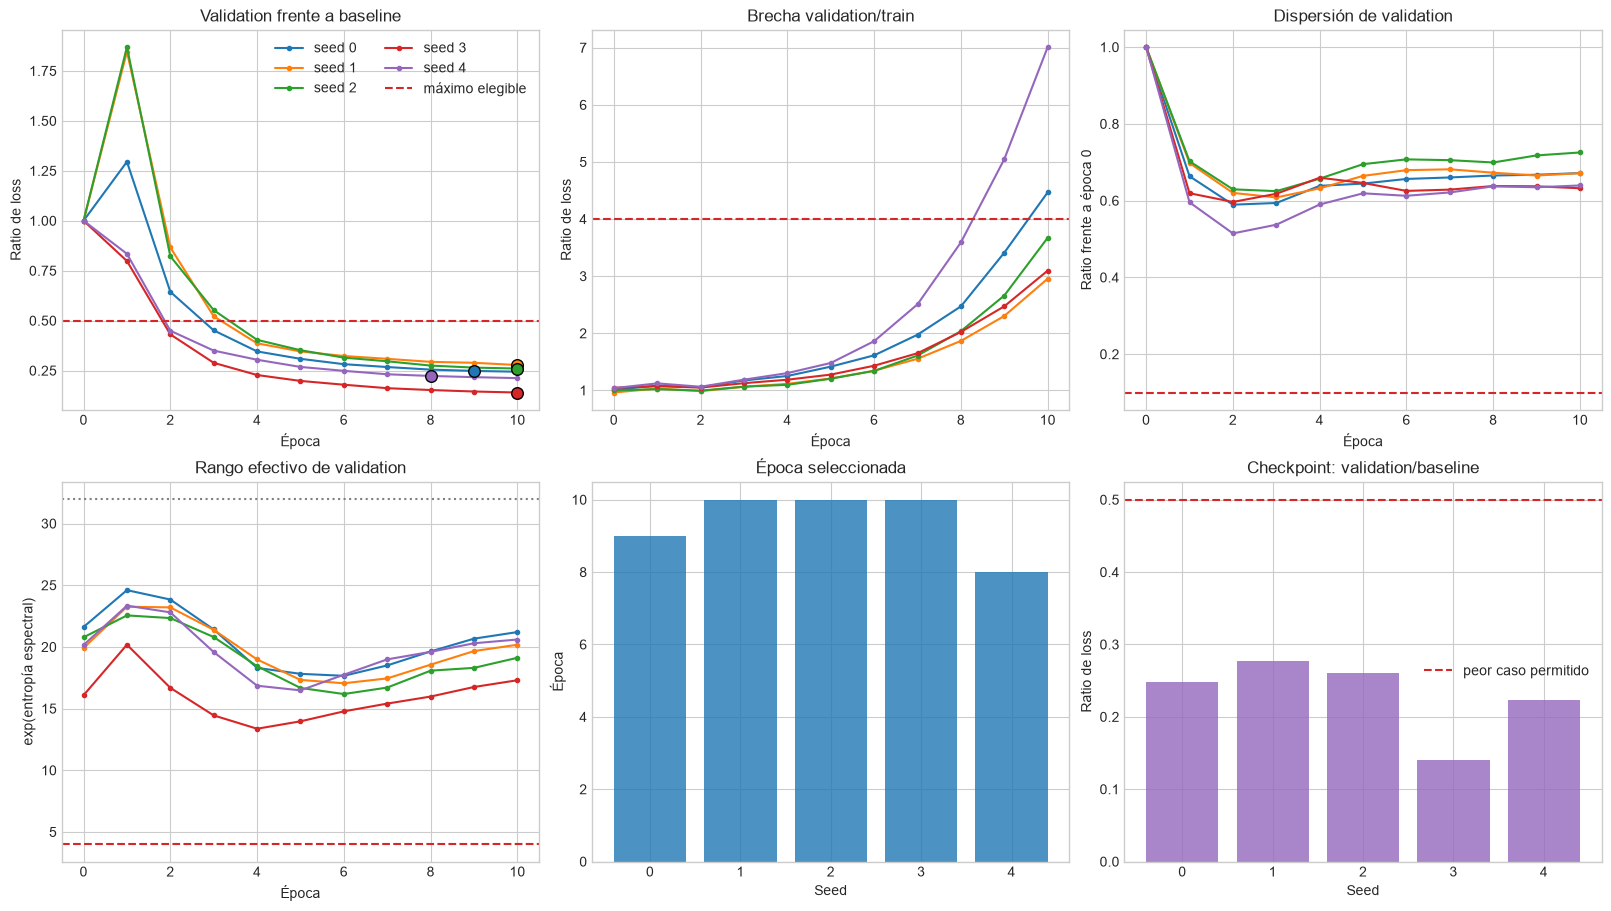

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for seed, history in histories.items():
    epochs = np.array([row.epoch for row in history])
    train_loss = np.array([row.train_loss for row in history])
    validation_loss = np.array([row.validation_loss for row in history])
    validation_std = np.array([row.validation_embedding_std for row in history])
    validation_rank = np.array([row.validation_effective_rank for row in history])
    gap = validation_loss / np.maximum(train_loss, 1e-12)
    line = axes[0, 0].plot(epochs, validation_loss / validation_loss[0], marker="o", markersize=3, label=f"seed {seed}")[0]
    axes[0, 1].plot(epochs, gap, marker="o", markersize=3, color=line.get_color())
    axes[0, 2].plot(epochs, validation_std / validation_std[0], marker="o", markersize=3, color=line.get_color())
    axes[1, 0].plot(epochs, validation_rank, marker="o", markersize=3, color=line.get_color())
    selection = selections[seed]
    if selection is not None:
        axes[0, 0].scatter(selection.epoch, selection.validation_loss_ratio, color=line.get_color(), edgecolor="black", s=70, zorder=5)

axes[0, 0].axhline(config.checkpoint_gate.max_validation_loss_ratio, color="tab:red", linestyle="--", label="máximo elegible")
axes[0, 0].set(title="Validation frente a baseline", xlabel="Época", ylabel="Ratio de loss")
axes[0, 0].legend(ncol=2)

axes[0, 1].axhline(config.checkpoint_gate.max_validation_train_loss_ratio, color="tab:red", linestyle="--")
axes[0, 1].set(title="Brecha validation/train", xlabel="Época", ylabel="Ratio de loss")

axes[0, 2].axhline(config.checkpoint_gate.min_validation_embedding_std_ratio, color="tab:red", linestyle="--")
axes[0, 2].set(title="Dispersión de validation", xlabel="Época", ylabel="Ratio frente a época 0")

axes[1, 0].axhline(config.checkpoint_gate.min_validation_effective_rank, color="tab:red", linestyle="--")
axes[1, 0].axhline(config.model.latent_dim, color="0.5", linestyle=":")
axes[1, 0].set(title="Rango efectivo de validation", xlabel="Época", ylabel="exp(entropía espectral)")

if summaries:
    seed_values = np.array([summary.seed for summary in summaries])
    selected_epochs = np.array([summary.checkpoint_epoch for summary in summaries])
    selected_ratios = np.array([summary.validation_loss_ratio for summary in summaries])
    axes[1, 1].bar(seed_values, selected_epochs, color="tab:blue", alpha=0.8)
    axes[1, 2].bar(seed_values, selected_ratios, color="tab:purple", alpha=0.8)
axes[1, 1].set(title="Época seleccionada", xlabel="Seed", ylabel="Época")
axes[1, 2].axhline(config.stability_gate.max_worst_validation_loss_ratio, color="tab:red", linestyle="--", label="peor caso permitido")
axes[1, 2].set(title="Checkpoint: validation/baseline", xlabel="Seed", ylabel="Ratio de loss")
axes[1, 2].legend()

plt.show()

In [7]:
status = "PASS" if gate.passed else "FAIL"
if summaries:
    worst_loss_summary = max(summaries, key=lambda row: row.validation_loss_ratio)
    worst_gap_summary = max(summaries, key=lambda row: row.validation_train_loss_ratio)
    worst_spread_summary = min(summaries, key=lambda row: row.validation_embedding_std_ratio)
    worst_rank_summary = min(summaries, key=lambda row: row.validation_effective_rank)
    selected_epoch_text = ", ".join(
        f"{summary.seed}:{summary.checkpoint_epoch}" for summary in summaries
    )
    selected_losses = np.array([summary.validation_loss for summary in summaries])
    selected_loss_ratios = np.array(
        [summary.validation_loss_ratio for summary in summaries]
    )
    absolute_loss_range_factor = selected_losses.max() / selected_losses.min()
    relative_loss_ratio_cv = selected_loss_ratios.std() / selected_loss_ratios.mean()
else:
    worst_loss_summary = worst_gap_summary = None
    worst_spread_summary = worst_rank_summary = None
    selected_epoch_text = "ninguno"
    absolute_loss_range_factor = float("nan")
    relative_loss_ratio_cv = float("nan")
final_gaps = {
    seed: history[-1].validation_loss / max(history[-1].train_loss, 1e-12)
    for seed, history in histories.items()
}
ineligible_final_seeds = [
    seed
    for seed, gap in final_gaps.items()
    if gap > config.checkpoint_gate.max_validation_train_loss_ratio
]
ineligible_final_text = ", ".join(str(seed) for seed in ineligible_final_seeds) or "ninguna"

decision = (
    "La optimización es suficientemente repetible para diseñar la persistencia de checkpoints y la evaluación final todavía ciega."
    if gate.passed
    else "No corresponde abrir test: el gate predefinido falla y el criterio de variabilidad debe revisarse en un protocolo nuevo, no dentro de esta corrida."
)

display(Markdown(f"""## Resultado e interpretación

- **Gate global: {status}.**
- **Checkpoints:** {'PASS' if gate.all_checkpoints_selected else 'FAIL'}; épocas por seed = `{selected_epoch_text}`.
- **Variabilidad:** CV de las validation loss seleccionadas = `{gate.validation_loss_coefficient_of_variation:.3f}` frente al máximo `{config.stability_gate.max_validation_loss_coefficient_of_variation:.2f}`.
- **Peor mejora:** validation/baseline = `{gate.worst_validation_loss_ratio:.3f}` frente al máximo `{config.stability_gate.max_worst_validation_loss_ratio:.2f}`.
- **Peor brecha:** validation/train = `{gate.worst_validation_train_loss_ratio:.3f}` frente al máximo `{config.stability_gate.max_worst_validation_train_loss_ratio:.1f}`.
- **Peor dispersión:** retención `{gate.worst_validation_embedding_std_ratio:.1%}` frente al mínimo `{config.stability_gate.min_worst_validation_embedding_std_ratio:.1%}`.
- **Peor rango efectivo:** `{gate.worst_validation_effective_rank:.3f}` frente al mínimo `{config.stability_gate.min_worst_validation_effective_rank:.1f}`.

### Lectura

Los puntos con borde negro son los checkpoints elegidos. Las trayectorias completas permiten comprobar si la política evita las épocas donde train continúa mejorando pero la brecha supera 4. Los peores casos pertenecen a seed `{worst_loss_summary.seed if worst_loss_summary else 'N/A'}` en mejora, seed `{worst_gap_summary.seed if worst_gap_summary else 'N/A'}` en brecha, seed `{worst_spread_summary.seed if worst_spread_summary else 'N/A'}` en dispersión y seed `{worst_rank_summary.seed if worst_rank_summary else 'N/A'}` en rango.

La política descarta específicamente las épocas finales de seeds `{ineligible_final_text}`, cuya brecha ya supera 4, y selecciona una época anterior elegible. Esto confirma que la restricción evita aceptar automáticamente el último modelo.

El único criterio global que falla es el CV de las loss absolutas. La mayor loss seleccionada es `{absolute_loss_range_factor:.2f}x` la menor. Como JEPA no fija la escala absoluta del espacio latente, esta cantidad mezcla calidad predictiva y escala de representación. Como diagnóstico exploratorio —no como gate—, el CV de los ratios normalizados validation/baseline es `{relative_loss_ratio_cv:.3f}`, menor que el CV absoluto `{gate.validation_loss_coefficient_of_variation:.3f}`. Este hallazgo puede motivar un protocolo v2 explícitamente invariante a escala, pero no cambia el FAIL actual.

### Decisión

{decision} Esta prueba mantiene fijo el dataset, por lo que **no mide** variabilidad entre muestras ni reproduce los resultados publicados. El split de test no fue instanciado ni consultado.
"""))

## Resultado e interpretación

- **Gate global: FAIL.**
- **Checkpoints:** PASS; épocas por seed = `0:9, 1:10, 2:10, 3:10, 4:8`.
- **Variabilidad:** CV de las validation loss seleccionadas = `0.288` frente al máximo `0.25`.
- **Peor mejora:** validation/baseline = `0.278` frente al máximo `0.50`.
- **Peor brecha:** validation/train = `3.671` frente al máximo `4.0`.
- **Peor dispersión:** retención `63.2%` frente al mínimo `10.0%`.
- **Peor rango efectivo:** `17.296` frente al mínimo `4.0`.

### Lectura

Los puntos con borde negro son los checkpoints elegidos. Las trayectorias completas permiten comprobar si la política evita las épocas donde train continúa mejorando pero la brecha supera 4. Los peores casos pertenecen a seed `1` en mejora, seed `2` en brecha, seed `3` en dispersión y seed `3` en rango.

La política descarta específicamente las épocas finales de seeds `0, 4`, cuya brecha ya supera 4, y selecciona una época anterior elegible. Esto confirma que la restricción evita aceptar automáticamente el último modelo.

El único criterio global que falla es el CV de las loss absolutas. La mayor loss seleccionada es `2.34x` la menor. Como JEPA no fija la escala absoluta del espacio latente, esta cantidad mezcla calidad predictiva y escala de representación. Como diagnóstico exploratorio —no como gate—, el CV de los ratios normalizados validation/baseline es `0.210`, menor que el CV absoluto `0.288`. Este hallazgo puede motivar un protocolo v2 explícitamente invariante a escala, pero no cambia el FAIL actual.

### Decisión

No corresponde abrir test: el gate predefinido falla y el criterio de variabilidad debe revisarse en un protocolo nuevo, no dentro de esta corrida. Esta prueba mantiene fijo el dataset, por lo que **no mide** variabilidad entre muestras ni reproduce los resultados publicados. El split de test no fue instanciado ni consultado.
